# 🏦 CFPB Consumer Complaints — Exploratory Data Analysis

**Notebook 1 of the MSBA Team 2 Trends Project.**

This notebook:
1. Loads the first 100,000 rows of the full CFPB complaints CSV
2. Saves that sample to `data/sample/cfpb_100k.csv` so the whole team can use it without downloading the 8.4 GB file
3. Counts total rows in the full file using chunked reading (so we don't load 8.4 GB into RAM)
4. Runs exploratory analysis on the 100k sample: nulls, product/issue/company distributions, time trends, narrative length, dispute & timeliness rates

> The full file is gitignored. Each teammate must download their own copy from the CFPB (see `data/README_data.md`).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

FULL_CSV_PATH = "/Users/kyle_z/Documents/UMN/SPRING/Big Data Analytics/Group Project/Working_file/msba-team2-trendsproject/complaints.csv"
SAMPLE_OUT_PATH = "../data/sample/cfpb_100k.csv"
SAMPLE_SIZE = 100_000

## Step 1 — Load the first 100,000 rows

We use `pd.read_csv(..., nrows=100_000)` so only the first chunk is parsed. This is fast (~a few seconds) and gives us a workable sample for local development.

In [2]:
df = pd.read_csv(FULL_CSV_PATH, nrows=SAMPLE_SIZE, low_memory=False)

# Normalize column names: lowercase, spaces/dashes -> underscores, strip '?'
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_", regex=False)
      .str.replace("-", "_", regex=False)
      .str.replace("?", "", regex=False)
)

print(f"Loaded {len(df):,} rows with {df.shape[1]} columns.")
print("Columns:", list(df.columns))

Loaded 100,000 rows with 18 columns.
Columns: ['date_received', 'product', 'sub_product', 'issue', 'sub_issue', 'consumer_complaint_narrative', 'company_public_response', 'company', 'state', 'zip_code', 'tags', 'consumer_consent_provided', 'submitted_via', 'date_sent_to_company', 'company_response_to_consumer', 'timely_response', 'consumer_disputed', 'complaint_id']


In [3]:
# Save the sample so teammates can use it without downloading the 8.4GB file
os.makedirs(os.path.dirname(SAMPLE_OUT_PATH), exist_ok=True)
df.to_csv(SAMPLE_OUT_PATH, index=False)
print(f"Sample saved to: {SAMPLE_OUT_PATH}")
print(f"Size on disk: {os.path.getsize(SAMPLE_OUT_PATH) / 1e6:.1f} MB")

Sample saved to: ../data/sample/cfpb_100k.csv
Size on disk: 58.7 MB


## Step 2 — Count total rows in the full CSV (chunked)

We can't load 8.4 GB into memory, so we iterate through the file in 500k-row chunks and sum the counts. This is O(n) on disk but constant in memory.

In [4]:
total_rows = 0
chunk_size = 500_000
for chunk in pd.read_csv(FULL_CSV_PATH, chunksize=chunk_size, low_memory=False, usecols=[0]):
    total_rows += len(chunk)

print(f"Total rows in full CFPB file: {total_rows:,}")

Total rows in full CFPB file: 14,350,572


## Step 3 — Basic shape and structure of the sample

Looking at shape, column names, dtypes, and the first few rows gives us a feel for what we're working with.

In [5]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nDtypes:")
print(df.dtypes)

Shape: (100000, 18)

Columns:
 ['date_received', 'product', 'sub_product', 'issue', 'sub_issue', 'consumer_complaint_narrative', 'company_public_response', 'company', 'state', 'zip_code', 'tags', 'consumer_consent_provided', 'submitted_via', 'date_sent_to_company', 'company_response_to_consumer', 'timely_response', 'consumer_disputed', 'complaint_id']

Dtypes:
date_received                     str
product                           str
sub_product                       str
issue                             str
sub_issue                         str
consumer_complaint_narrative      str
company_public_response           str
company                           str
state                             str
zip_code                          str
tags                              str
consumer_consent_provided         str
submitted_via                     str
date_sent_to_company              str
company_response_to_consumer      str
timely_response                   str
consumer_disputed            

In [6]:
df.head()

,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zip_code,tags,consumer_consent_provided,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,consumer_disputed,complaint_id
0,2020-07-06,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,346XX,NaN,Other,Web,2020-07-06,Closed with explanation,Yes,NaN,3730948
1,2019-12-26,Credit card or prepaid card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...",Confusing or misleading advertising about the ...,NaN,NaN,CAPITAL ONE FINANCIAL CORPORATION,CA,94025,NaN,Consent not provided,Web,2019-12-26,Closed with explanation,Yes,NaN,3477549
2,2020-05-08,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,These are not my accounts.,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,NV,89030,NaN,Consent provided,Web,2020-05-08,Closed with explanation,Yes,NaN,3642453
3,2024-01-05,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,Kindly address this issue on my credit report....,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,IL,60502,NaN,Consent provided,Web,2024-01-05,Closed with non-monetary relief,Yes,NaN,8113747
4,2024-01-21,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,NC,27401,Servicemember,Consent not provided,Web,2024-01-21,Closed with explanation,Yes,NaN,8191825


## Step 4 — Null values per column

This tells us which columns are reliable and which are sparse. `consumer_complaint_narrative` is typically very sparse (only filled when consumers opt in), which matters for BERTopic.

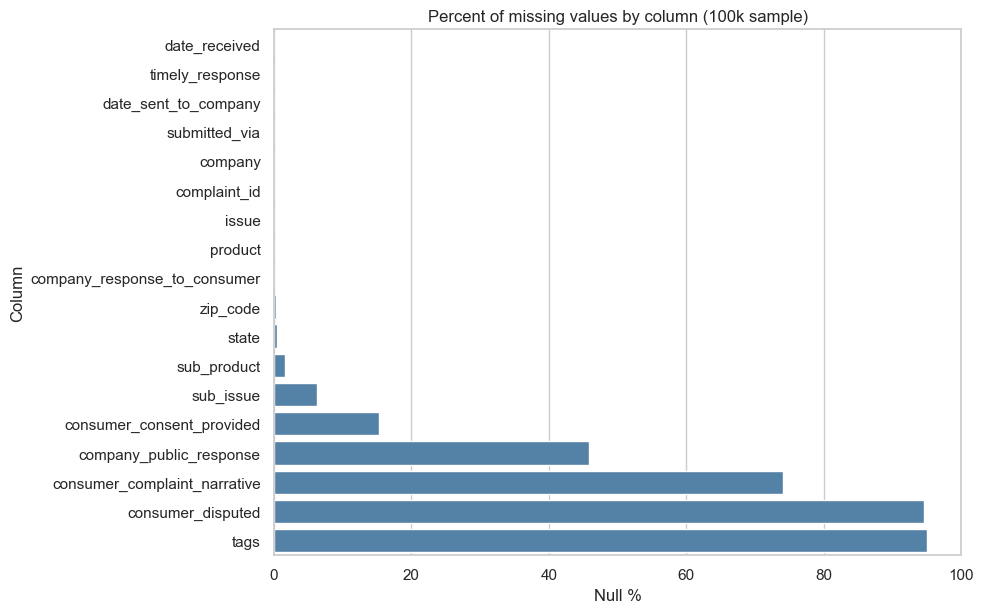

date_received                    0.00
timely_response                  0.00
date_sent_to_company             0.00
submitted_via                    0.00
company                          0.00
complaint_id                     0.00
issue                            0.00
product                          0.00
company_response_to_consumer     0.00
zip_code                         0.22
state                            0.43
sub_product                      1.62
sub_issue                        6.27
consumer_consent_provided       15.27
company_public_response         45.77
consumer_complaint_narrative    74.01
consumer_disputed               94.60
tags                            94.99
dtype: float64


In [7]:
null_pct = (df.isna().mean() * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(null_pct))))
sns.barplot(x=null_pct.values, y=null_pct.index, ax=ax, color="steelblue")
ax.set_xlabel("Null %")
ax.set_ylabel("Column")
ax.set_title("Percent of missing values by column (100k sample)")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

print(null_pct.round(2))

## Step 5 — How many rows have a consumer complaint narrative?

BERTopic only runs on rows where `consumer_complaint_narrative` is present, so this number sets a ceiling on the text-modeling sample size.

In [8]:
has_narrative = df["consumer_complaint_narrative"].notna().sum()
pct = has_narrative / len(df) * 100
print(f"Rows with a narrative: {has_narrative:,} / {len(df):,} ({pct:.1f}%)")

Rows with a narrative: 25,992 / 100,000 (26.0%)


## Step 6 — Top 20 products

Which financial products get the most complaints? This is the coarsest view of where consumer pain is concentrated.

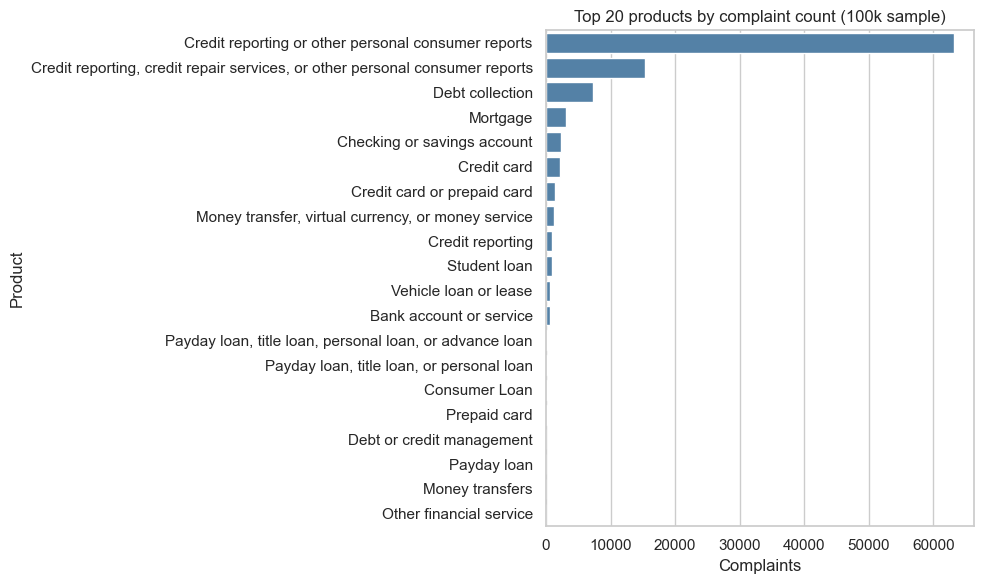

In [9]:
top_products = df["product"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, ax=ax, color="steelblue")
ax.set_title("Top 20 products by complaint count (100k sample)")
ax.set_xlabel("Complaints")
ax.set_ylabel("Product")
plt.tight_layout()
plt.show()

## Step 7 — Top 20 issues

One level deeper: what *types* of problems are most common?

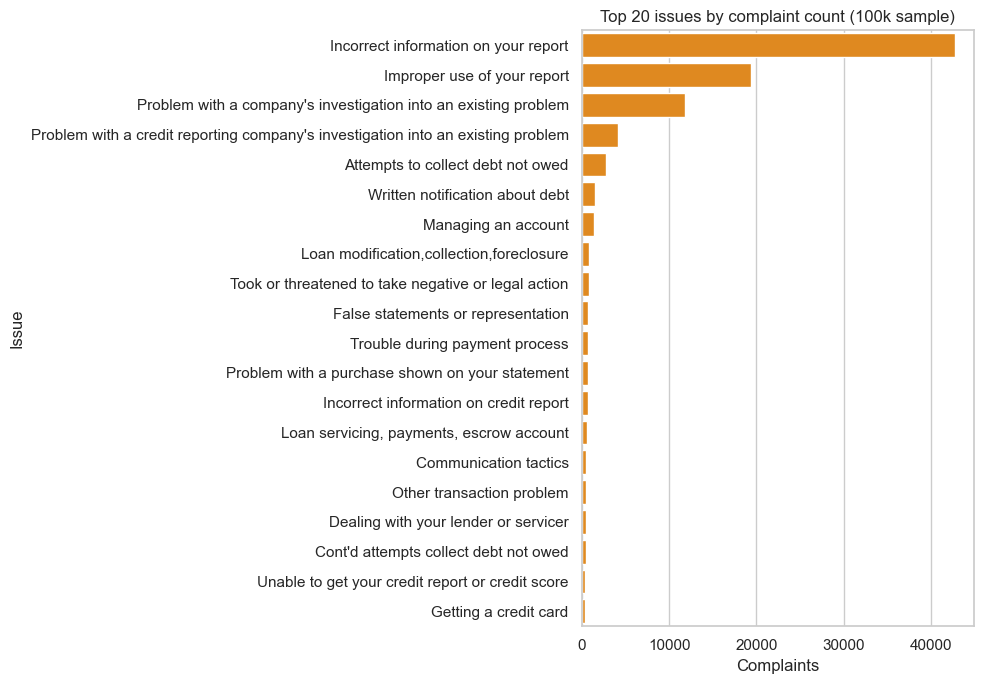

In [10]:
top_issues = df["issue"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_issues.values, y=top_issues.index, ax=ax, color="darkorange")
ax.set_title("Top 20 issues by complaint count (100k sample)")
ax.set_xlabel("Complaints")
ax.set_ylabel("Issue")
plt.tight_layout()
plt.show()

## Step 8 — Top 20 companies

Which firms receive the most complaints? Useful for identifying systemic offenders vs. niche issues.

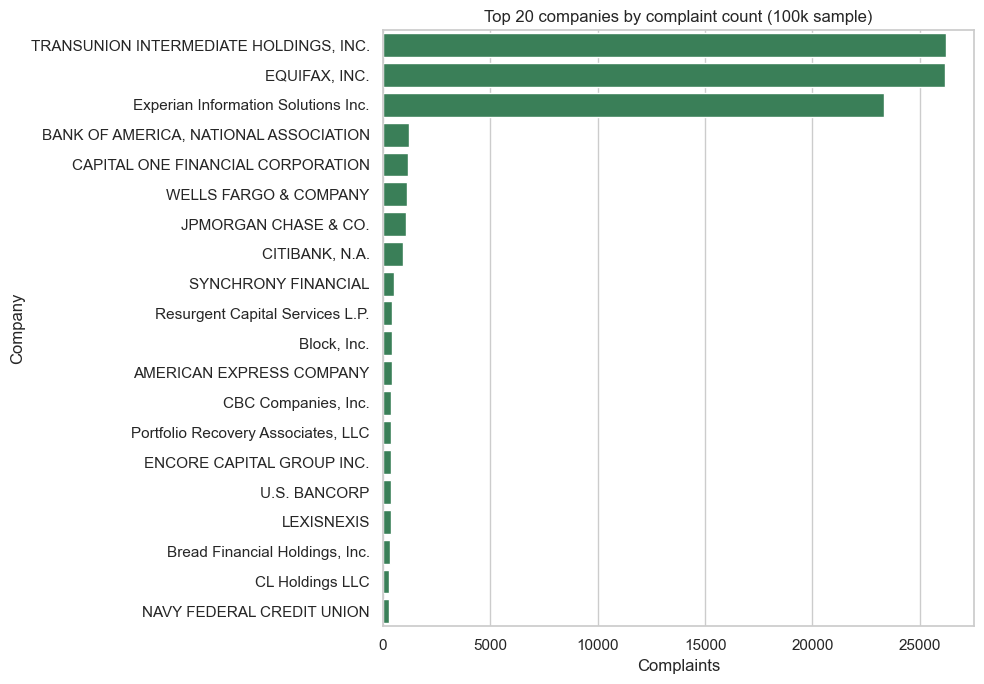

In [11]:
top_companies = df["company"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_companies.values, y=top_companies.index, ax=ax, color="seagreen")
ax.set_title("Top 20 companies by complaint count (100k sample)")
ax.set_xlabel("Complaints")
ax.set_ylabel("Company")
plt.tight_layout()
plt.show()

## Step 9 — Complaint volume over time

Monthly complaint counts show whether complaint volume is trending up or seasonal. Keep in mind the 100k sample is only the first 100k rows, so this reflects whatever date range the CSV starts with, not the whole history.

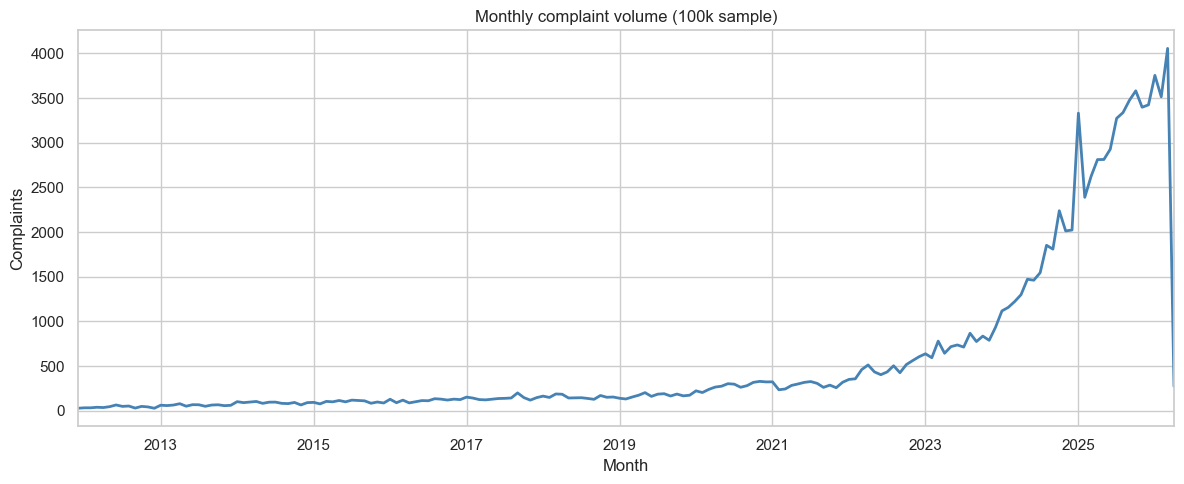

Date range in sample: 2011-12-01 → 2026-04-04


In [12]:
df["date_received"] = pd.to_datetime(df["date_received"], errors="coerce")
monthly = df.dropna(subset=["date_received"]).set_index("date_received").resample("MS").size()

fig, ax = plt.subplots(figsize=(12, 5))
monthly.plot(ax=ax, color="steelblue", linewidth=2)
ax.set_title("Monthly complaint volume (100k sample)")
ax.set_xlabel("Month")
ax.set_ylabel("Complaints")
plt.tight_layout()
plt.show()

print(f"Date range in sample: {df['date_received'].min().date()} → {df['date_received'].max().date()}")

## Step 10 — Distribution of `company_response_to_consumer`

How do companies typically close out complaints? "Closed with explanation" dominates but the long tail is interesting.

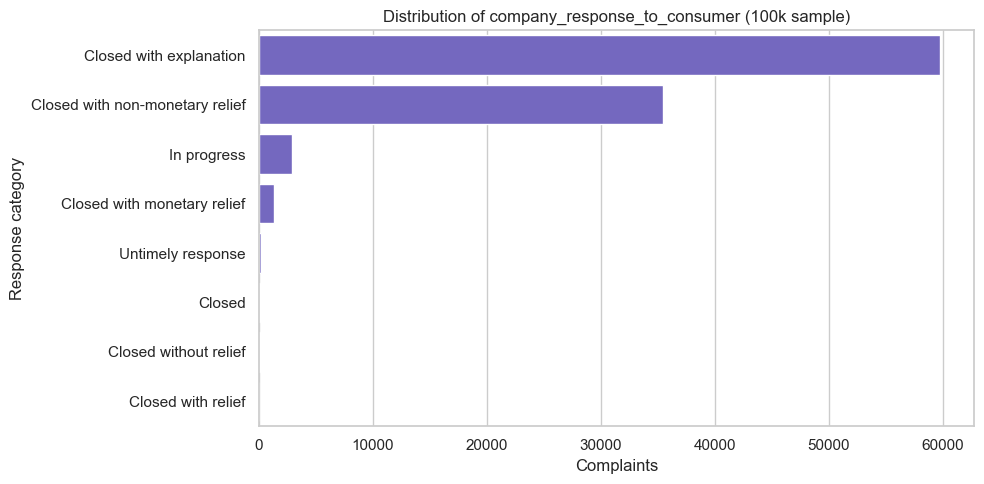

company_response_to_consumer
Closed with explanation            59763
Closed with non-monetary relief    35493
In progress                         2880
Closed with monetary relief         1383
Untimely response                    163
Closed                               142
Closed without relief                138
Closed with relief                    36
Name: count, dtype: int64


In [13]:
resp = df["company_response_to_consumer"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=resp.values, y=resp.index, ax=ax, color="slateblue")
ax.set_title("Distribution of company_response_to_consumer (100k sample)")
ax.set_xlabel("Complaints")
ax.set_ylabel("Response category")
plt.tight_layout()
plt.show()

print(resp)

## Step 11 — Consumer disputed (Yes/No/null)

This field is often sparse in newer rows but tells us which cases the consumer was not satisfied with.

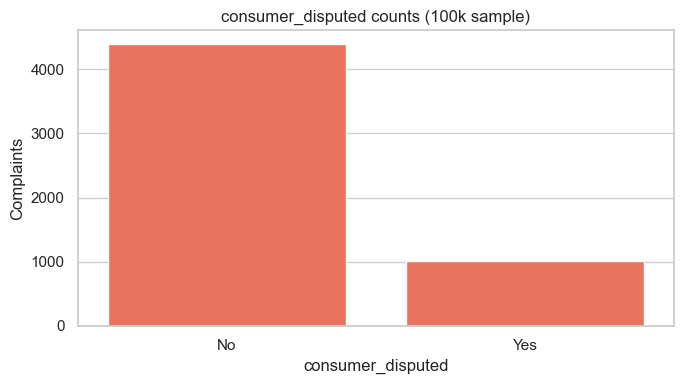

consumer_disputed
NaN    94599
No      4384
Yes     1017
Name: count, dtype: int64


In [14]:
disputed = df["consumer_disputed"].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=disputed.index.astype(str), y=disputed.values, ax=ax, color="tomato")
ax.set_title("consumer_disputed counts (100k sample)")
ax.set_xlabel("consumer_disputed")
ax.set_ylabel("Complaints")
plt.tight_layout()
plt.show()

print(disputed)

## Step 12 — Timely response (Yes/No)

Regulatory / service-quality signal — how often is the company's response on time?

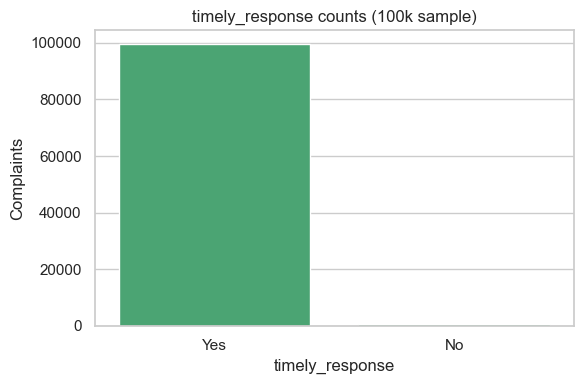

timely_response
Yes    99366
No       634
Name: count, dtype: int64


In [15]:
timely = df["timely_response"].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=timely.index.astype(str), y=timely.values, ax=ax, color="mediumseagreen")
ax.set_title("timely_response counts (100k sample)")
ax.set_xlabel("timely_response")
ax.set_ylabel("Complaints")
plt.tight_layout()
plt.show()

print(timely)

## Step 13 — Narrative length analysis

For rows that have a narrative, how long are they? Length affects BERTopic — very short narratives often cluster as outliers.  
We compute both character length and word count and visualize the character-length distribution.

Rows with narrative: 25,992
Avg chars per narrative: 1023 (median 663)
Avg words per narrative: 178 (median 117)


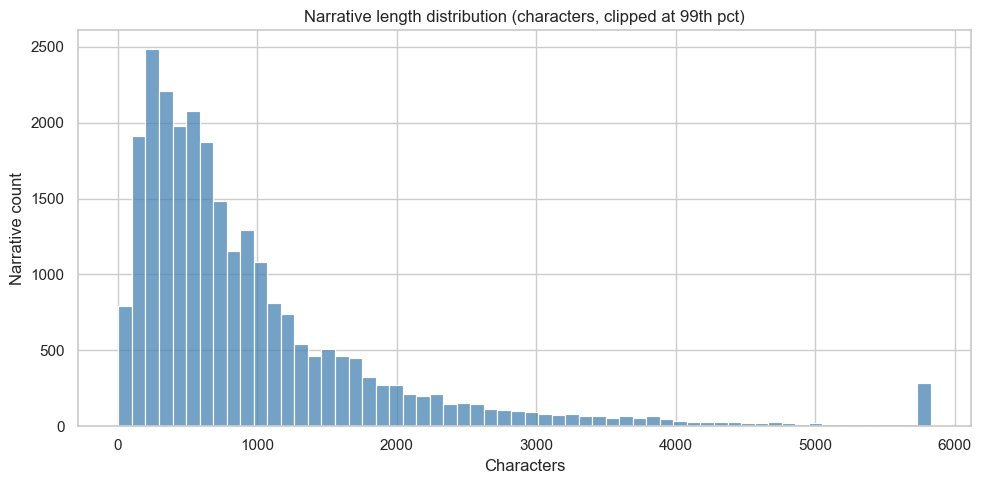

In [16]:
narr = df.loc[df["consumer_complaint_narrative"].notna(), "consumer_complaint_narrative"].astype(str)

char_len = narr.str.len()
word_len = narr.str.split().str.len()

print(f"Rows with narrative: {len(narr):,}")
print(f"Avg chars per narrative: {char_len.mean():.0f} (median {char_len.median():.0f})")
print(f"Avg words per narrative: {word_len.mean():.0f} (median {word_len.median():.0f})")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(char_len.clip(upper=char_len.quantile(0.99)), bins=60, ax=ax, color="steelblue")
ax.set_title("Narrative length distribution (characters, clipped at 99th pct)")
ax.set_xlabel("Characters")
ax.set_ylabel("Narrative count")
plt.tight_layout()
plt.show()

## ✅ End of Notebook 1

**What we have now:**
- `data/sample/cfpb_100k.csv` — a shareable 100k-row sample
- A total row count for the full file
- A first look at nulls, products, issues, companies, time trends, responses, disputes, timeliness, and narrative length

**Next notebook (`02_bertopic_test.ipynb`):** run a small BERTopic experiment on the narratives to see if the sub-theme clustering works as expected.